In [1]:
import pytesseract
from PIL import Image
import cv2
import numpy as np

import re
import pandas as pd

pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

In [2]:
def preprocess_img_gray(image_path):
    """Preprocess DOSBox screenshot for better OCR"""
    
    img = cv2.imread(image_path)
    #Read image
    
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    #Convert to grayscale

    _, thresh = cv2.threshold(img_gray, 100, 255, cv2.THRESH_BINARY)

    denoised = cv2.fastNlMeansDenoising(thresh)
    #Denoise

    return img, img_gray, denoised


def extract_salary_auction_info(salary_auction_frame):
    player = salary_auction_frame[2].split(' ')[1]
    player_pos = salary_auction_frame[3].split(' ')[1]
    player_str = salary_auction_frame[5].split(' ')[1]
    player_team = salary_auction_frame[7].split(' ')[2]
    player_price = salary_auction_frame[9].split(' ')[2]
    player_minimum_wage = salary_auction_frame[11].split(' ')[2]
    
    return {
        'name': player,
        'position': player_pos,
        'strength': player_str,
        'team': player_team,
        'price': player_price,
        'minimum_wage': player_minimum_wage
    }

def img_processing(img):
    img = cv2.resize(img, None, fx=3, fy=3, interpolation=cv2.INTER_NEAREST)
    if np.mean(img) < 127:
        img = cv2.bitwise_not(img)
    return img


def prepare_dos_for_ocr(gray):
    # 1. Load image
    #img = cv2.imread(image_path)
    
    # 2. Convert to Grayscale
    #gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # 3. Upscale (Crucial for low-res DOS fonts)
    img_resized = cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_NEAREST)
    
    # 4. Threshold & Invert (Assuming light text on dark background)
    # This creates Black text on a White background
    _, processed_img = cv2.threshold(img_resized, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    return processed_img


def extract_squad_info(image_path, config = '--psm 6'):
    
    img, img_gray, img_denoised = preprocess_img_gray(image_path)
    img_denoised = img_gray

    img_denoised = img_processing(img)
    img_nrs = prepare_dos_for_ocr(img_gray)

    player_text = pytesseract.image_to_string(Image.fromarray(img_denoised[0:300,0:150]), config=config)

    all_pos = []
    all_names = []
    pos = 'G'
    for row in player_text.split('\n'):
        if row.strip() == '':
            continue
        row_components = row.split(' ')
        if row_components[0] == 'G':
            pos = row_components.pop(0)
        if row_components[0] == 'D':
            pos = row_components.pop(0)
        elif row_components[0] == 'M':
            pos = row_components.pop(0)
        elif row_components[0] == 'A' or row_components[0] == '@':
            pos = row_components.pop(0)
        all_pos += [pos]
        all_names += [' '.join(row_components)]

    processed_img_sth =  prepare_dos_for_ocr(img_gray[0:300,200:230])
    sth_values = process_nrs(processed_img_sth)

    processed_img_slr =  prepare_dos_for_ocr(img_gray[0:300,230:265])
    slr_values = process_nrs(processed_img_slr)

    processed_img_goals =  prepare_dos_for_ocr(img_gray[0:300,310:335])
    goals_values = process_nrs(processed_img_goals)

    squad_df = pd.DataFrame({'Position': all_pos, 'Name': all_names, 'Strength': sth_values, 'Salary': slr_values, 'Goals': goals_values})
    return squad_df


def process_nrs(img_section, config='--psm 6 --oem 3 -c tessedit_char_whitelist=0123456789'):
    nrs_text = pytesseract.image_to_string(Image.fromarray(img_section), config=config)
    nrs_values = [int(nrs_v) for nrs_v in nrs_text.split('\n') if re.match(r'\d+', nrs_v)]
    return nrs_values

def extract_squad_nrs(image_path):
    img, img_gray, img_denoised = preprocess_img_gray(image_path)

    processed_img_sth =  prepare_dos_for_ocr(img_gray[0:300,200:230])
    sth_values = process_nrs(processed_img_sth)

    processed_img_slr =  prepare_dos_for_ocr(img_gray[0:300,230:265])
    slr_values = process_nrs(processed_img_slr)

    processed_img_goals =  prepare_dos_for_ocr(img_gray[0:300,310:335])
    goals_values = process_nrs(processed_img_goals)

    squad_df = pd.DataFrame({'Strength': sth_values, 'Salary': slr_values, 'Goals': goals_values})

    return squad_df

In [3]:
import os

results = []
results_d = {}
squad_frames = 'Data\Frames_Categories\Squad'

counter = 0
for squad_frame in os.listdir(squad_frames):
    try:
        specific_squad_frame = os.path.join(squad_frames, squad_frame)
        counter += 1
        squad_df = extract_squad_nrs(specific_squad_frame)
        results_d[counter] = squad_df
    except Exception as e:
        print(f"Error processing {squad_frame}: {e}")
        1/0


Error processing 1766256759.8661506_esc_esc.jpeg: All arrays must be of the same length


ZeroDivisionError: division by zero

In [4]:
extract_squad_nrs(specific_squad_frame)

ValueError: All arrays must be of the same length

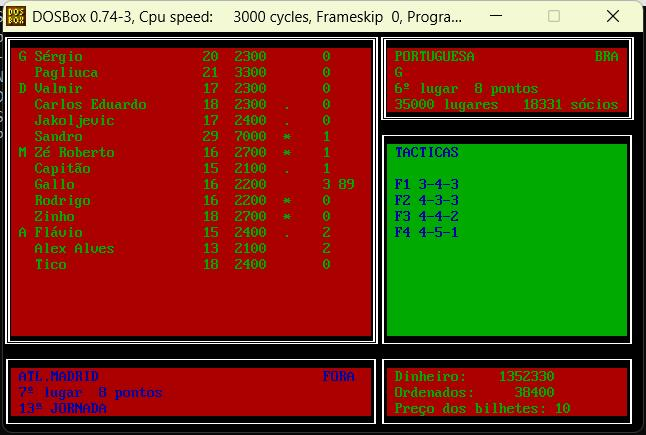

In [17]:
Image.open(specific_squad_frame)

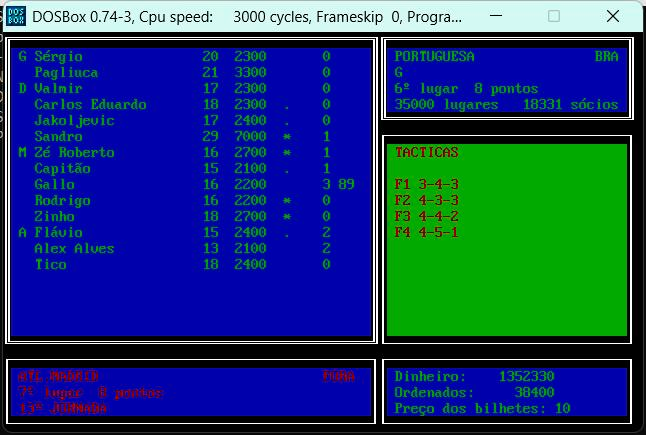

In [18]:
from PIL import Image

img = cv2.imread(specific_squad_frame)
Image.fromarray(img)

In [19]:
squad_df = extract_squad_nrs(specific_squad_frame)

ValueError: All arrays must be of the same length

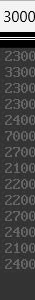

In [27]:
Image.fromarray(img_gray[0:300,230:265])

In [25]:
img, img_gray, img_denoised = preprocess_img_gray(specific_squad_frame)

processed_img_sth =  prepare_dos_for_ocr(img_gray[0:300,200:230])
sth_values = process_nrs(processed_img_sth)

processed_img_slr =  prepare_dos_for_ocr(img_gray[0:300,230:265])
slr_values = process_nrs(processed_img_slr)

processed_img_goals =  prepare_dos_for_ocr(img_gray[0:300,310:335])
goals_values = process_nrs(processed_img_goals)

squad_df = pd.DataFrame({'Strength': sth_values, 'Salary': slr_values, 'Goals': goals_values})

ValueError: All arrays must be of the same length

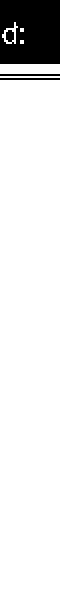

In [28]:
Image.fromarray(processed_img_sth)